 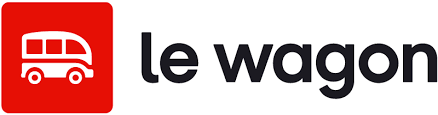

# Predict next fashion

Designing new products for a fashion line takes time. Taking finished products from design to market can have lead times of a year or more! Therefore, the ability to predict upcoming trends in the market has the potential to avoid financial losses and wastage.

With that in mind, let's try using social network signals to anticipate and predict the next big fashion trends!

## Load data

NameError: name 'pd' is not defined

a) Download the [`tendances.csv`](https://drive.google.com/file/d/15xv2daQ03RnTL8fHksHxQFC3yrU7VFVg/view?usp=drive_link) file and import it to Colab.

Let's take a look at the data. The columns represent different types of clothing and the rows represent dates between 2015 and 2019. The values correspond to an internal index related to their popularity on social networks.

We're trying to predict future values for each type of clothing.

Load the data into a `df` DataFrame. Use the parameter `index_col=0` to set the first column as the index.

What is the period? Weekly, monthly, ...?

b) Plot all the series on the same chart with `plotly.express`

c) Do you notice any clear trends (upwards or downwards) for any of the clothing items?

d) Can you recognise any instances of seasonality?

e) There's a quick way to confirm our intuition about the seasonality of these fashion trends. We can decompose time series data to see the `trend` + `seasonality` + `residuals`.

Execute the cell below to see the results for denim trousers.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# decompose time serie
r = seasonal_decompose(df['pants_denim'], period=52)

# save plot to fig variable
fig = r.plot()
# set custom dimensions
fig.set_figwidth(12)
fig.set_figheight(8)
plt.tight_layout()

# delete all x axis except
for ax in fig.get_axes():
    ax.set_xticks(list(range(0,209,26)))

f) Can you interpret the seasonality of denim trousers using the above results?

- Were there times throughout the year when denim trousers were more popular?

- What do you think you could say about the popularity of denim between 2015 and 2018 given these results?

Try modifying the code in the cell above to view the breakdowns of a few other items of clothing. Before running the code for each item, why not have a go at predicting the trends yourself? Were your fashion intuitions visionary or passé?

## Preprocessing data



a) To prepare the modelling, we need the DataFrame to be well formatted. In particular, we want to have:

- an index with a weekly frequency and a periodic type (e.g. `dtype: 'period[W-MON]'`)

- and a time type column named `date` (e.g. `dtype: datetime64[ns]`)

To achieve this we'll need to do the necessary pre-processing.

In [ ]:
# Create a new column 'date' containing the df.index cast into datetime format


# set index with date column values


# make index periodic


b) Now we'll need to split the train and test data. We will use the last year of data as our test set (`df_test`) and the rest for training (`df_train`).

We're going to use the `temporal_train_test_split` method. What should you put in the `test_size` parameter?

In [ ]:
!pip install sktime -q

## Modeling

### Modeling - Naive

For simplicity, we will restrict ourselves in this section to the `top_tanksleeve_tshirtneck` time series.

a) We're going to train a naive model by using `NaiveForecaster` from the `sktime` library.

Predict the last year's values and store the results in a variable with the name `naive_preds`.

In [ ]:
from sktime.forecasting.naive import NaiveForecaster

cloth = 'top_tanksleeve_tshirtneck'

# intialize model with a `sp` parameter

# fit model

# predict last year values, use list(range(1,53)) to create a list [1,2,...,52]


b) In `df_test` variable, create a new column `naive_model` which will contain the predictions of our naive model

Visualize both the predicted and real data with plotly express

<details>
    <summary>Hint 💡</summary>
The y parameter of a px.line() function can be a list of column names
</details>

In [ ]:
# create a new column "naive_model" with naive predictions


# visualize data


c) Calculate the MASE.

How do you interpret this metric? Does the result make sense?

<details>
    <summary>Answer</summary>
MASE or Mean Absolute Scaled Error is the mean absolute error of the forecasted values divided by the mean absolute error if we had forecasted using a naive model (read: if we had just taken the same values as the previous season).
Here we forecasted using a naive model, so we expected a value close to 1 anyway.
</details>



d) Calculate the MAE and SMAPE for the naive model.

Interpret these results.

<details>
    <summary>Answer</summary>
The Mean Absolute Error is about 0.0005. Since the time series oscillates globally between 0 and 0.005, the error is not bad: it is at 10% of the usual amplitude of this time series.

SMAPE, on the other hand, is at almost 50% error. This seems to be too much compared to our intuitive perception of the graph, and given the MAE.

The reason is this: SMAPE or Symmetric Mean Absolute Percentage Error, compares for each idividual point in time the error to the average of the true value and the forecast value (and then averages those over all the points in time).
Our time series has very low values, especially at the beginning and end of the year. So, if, like around February, for a true value of 0.0005, we predict 0.0010, in absolute terms this a small error, but in relative terms it is far off. And this is what SMAPE calculates: the error (0.0005) divided by the average of true and forecast value (0.00075) which gives 67% for this point!
</details>

### Modeling - Holt-Winters

Now that we have understood the outputs of our naive model, it's time to move on to a more advanced model. Let's try the Holt-Winters model.

In this model, we start from a base level (the last value of our train data before we start forecasting) and complete it with a trend component and a seasonal component.

e) Look closely at seasonality and trend, and determine how you want to model:

- the trend, which can be additive (`trend='add'`) or multiplicative (`trend='mul'`), starting from the base level

- the seasonality, which can also be additive (`seasonal='add'`) or multiplicative (`seasonal='mul'`)

Justify your choice.

<details>
    <summary>Answer</summary>

We should choose a multiplicative trend, because we are getting closer to 0: an additive model could drive the trend below this threshold! (If we start from a low base level, if we subtract the same amount each time, we'll end up below 0. If we multiply the low base level with the same value (less than 1), we'll get closer and closer to 0, but not below 0.)

We should choose an additive seasonality, because the maximum amplitude between summer and winter seems fixed year after year.

So we have: `trend='mul'` and `seasonal='add'
</details>

f) Apply a Holt-Winters model on this time series with trend and seasonal options.

Display the predictions.

In [ ]:
from sktime.forecasting.exp_smoothing import ExponentialSmoothing

# intialize model with trend `mul` and seasonal `add`


# fit model


# predict last year values, use list(range(1,53)) to create a list [1,2,...,52]


In [ ]:
# create a new column "holt_winters" with holt_winters predictions


# visualize data


g) Calculate error metrics for this new model (MAE, MASE and SMAPE) as you did questions c) and d).

Do you get a better performance? Interpret the results.

<details>
    <summary><i>Response</i></summary>

Predictions are very close to reality. We also observe an improvement according to all our metrics: this model is indeed an improvement compared to the naive model.

The MASE allows us to quantify specifically the improvement compared to the naive model: with a value of `0.68`, we can verify that our Holt-Winters model is 1/3 better than a naive model.
</details>